### 一、环境配置与依赖加载

In [10]:
# 1. 设置工作目录（替换为你的数据路径）
setwd("/Users/wangguotao/Downloads/ISAR/food/")

# 2. 安装必要包（首次运行取消注释）
# install.packages(c("readxl", "writexl", "dplyr", "tidyr", "ggplot2", "ggpubr", "car", "corrplot", "broom"))

# 3. 加载核心包
library(readxl)       # 读取Excel
library(writexl)      # 导出Excel
library(dplyr)        # 数据清洗
library(tidyr)        # 数据重塑
library(ggplot2)      # 可视化
library(ggpubr)       # 组合图表
library(car)          # 方差分析/交互检验
library(corrplot)     # 相关性可视化
library(broom)        # 统计结果整理
library(stringr)      # 字符串处理

# 4. 全局设置（解决中文显示问题）
Sys.setlocale("LC_ALL", "zh_CN.UTF-8")  # Mac/Linux
# Sys.setlocale("LC_ALL", "Chinese")     # Windows
theme_set(theme_bw() + theme(text = element_text(family = "Arial Unicode MS")))  # 中文字体
options(warn = -1)  # 关闭无关警告

[1] "zh_CN.UTF-8/zh_CN.UTF-8/zh_CN.UTF-8/C/zh_CN.UTF-8/zh_CN"

### 二、数据加载函数

In [11]:
load_data <- function(main_path, fatigue_path) {
  # 加载主数据
  tryCatch({
    df_main <- read_excel(main_path)
    cat(sprintf("✅ 成功加载主数据：%s\n", main_path))
    cat(sprintf("主数据形状：%d行 × %d列\n", nrow(df_main), ncol(df_main)))
  }, error = function(e) {
    cat(sprintf("❌ 主数据加载失败：%s\n", e$message))
    return(list(df_main = NULL, df_fatigue = NULL))
  })
  
  # 加载疲劳量表（备用）
  tryCatch({
    df_fatigue <- read_excel(fatigue_path)
    cat(sprintf("✅ 成功加载疲劳量表：%s\n", fatigue_path))
    cat(sprintf("疲劳量表形状：%d行 × %d列\n", nrow(df_fatigue), ncol(df_fatigue)))
  }, error = function(e) {
    cat(sprintf("⚠️  疲劳量表加载失败：%s（不影响核心分析）\n", e$message))
    df_fatigue <- NULL
  })
  
  # 筛选核心变量
  key_vars <- colnames(df_main)[str_detect(colnames(df_main), 
    "性别|年龄|婚姻|身高|体重|人连蛋白|三种食物")]
  cat(sprintf("\n核心分析变量（共%d个）：\n", length(key_vars)))
  for (i in 1:length(key_vars)) {
    cat(sprintf("  %2d. %s\n", i, key_vars[i]))
  }
  
  return(list(df_main = df_main, df_fatigue = df_fatigue))
}

# 执行数据加载
data_list <- load_data(
  main_path = "信息汇总全_加阳性率+加权+二分类+3种食物加.xlsx",
  fatigue_path = "疲劳量表.xls"
)
df_main <- data_list$df_main

✅ 成功加载主数据：信息汇总全_加阳性率+加权+二分类+3种食物加.xlsx
主数据形状：102行 × 30列
✅ 成功加载疲劳量表：疲劳量表.xls
疲劳量表形状：102行 × 11列

核心分析变量（共10个）：
   1. 性别
   2. 年龄
   3. 婚姻
   4. 身高
   5. 体重
   6. 人连蛋白四参数结果
   7. 人连蛋白直线结果
   8. 人连蛋白四参数结果.1
   9. 人连蛋白直线结果.1
  10. 三种食物分类加权评分


### 三、数据清洗与预处理

In [12]:
clean_and_preprocess <- function(df) {
  df_clean <- df %>%
    # 1. 清理性别
    mutate(性别_clean = ifelse(性别 %in% c("男", "女"), 性别, NA)) %>%
    # 2. 清理婚姻状况
    mutate(婚姻_clean = str_replace(婚姻, "已婚·", "已婚")) %>%
    mutate(婚姻_clean = ifelse(婚姻_clean %in% c("已婚", "未婚", "离异"), 婚姻_clean, NA)) %>%
    # 3. 删除身高/体重缺失值
    drop_na(身高, 体重) %>%
    # 4. 计算BMI及分类（中国标准）
    mutate(BMI = 体重 / ((身高/100)^2)) %>%
    mutate(BMI分类 = case_when(
      BMI < 18.5 ~ "偏瘦",
      BMI >= 18.5 & BMI < 24 ~ "正常",
      BMI >= 24 & BMI < 28 ~ "超重",
      BMI >= 28 ~ "肥胖",
      TRUE ~ NA_character_
    )) %>%
    mutate(BMI分类合并 = ifelse(BMI分类 == "偏瘦", "正常", BMI分类)) %>%
    # 5. 年龄分层
    mutate(年龄分层 = case_when(
      年龄 <= 35 ~ "≤35岁",
      年龄 > 35 & 年龄 <= 45 ~ "36-45岁",
      年龄 > 45 & 年龄 <= 55 ~ "46-55岁",
      年龄 > 55 ~ ">55岁",
      TRUE ~ NA_character_
    )) %>%
    # 6. 选择核心变量
    select(
      性别_clean, 年龄分层, BMI分类, BMI分类合并, 婚姻_clean,
      三种食物分类加权评分, 人连蛋白四参数结果.1, 是否耐受, 年龄
    ) %>%
    # 7. 删除核心变量缺失值
    drop_na() %>%
    # 8. 创建编码变量（数值型）
    mutate(
      性别编码 = ifelse(性别_clean == "男", 1, 0),
      年龄连续 = as.numeric(年龄),  # 原始年龄（避免分类变量错误）
      BMI编码 = case_when(
        BMI分类合并 == "正常" ~ 1,
        BMI分类合并 == "超重" ~ 2,
        BMI分类合并 == "肥胖" ~ 3,
        TRUE ~ NA_real_
      )
    ) %>%
    # 转换为数值型（确保运算正常）
    mutate(
      三种食物分类加权评分 = as.numeric(三种食物分类加权评分),
      人连蛋白四参数结果.1 = as.numeric(人连蛋白四参数结果.1)
    )
  
  # 打印清洗结果
  cat(sprintf("\n📊 数据清洗结果：\n"))
  cat(sprintf("原始样本量：%d例 → 有效样本量：%d例\n", nrow(df), nrow(df_clean)))
  
  # 打印分层分布
  cat("\n各分层变量分布：\n")
  cat("  性别：\n")
  print(table(df_clean$性别_clean))
  cat("  年龄分层：\n")
  print(table(df_clean$年龄分层))
  cat("  BMI分类：\n")
  print(table(df_clean$BMI分类合并))
  cat("  婚姻状况：\n")
  print(table(df_clean$婚姻_clean))
  
  # 保存清洗后数据
  write.csv(df_clean, "cleaned_analysis_data.csv", row.names = FALSE, fileEncoding = "UTF-8")
  cat(sprintf("\n💾 清洗后数据已保存：%s/cleaned_analysis_data.csv\n", getwd()))
  
  return(df_clean)
}

# 执行数据清洗
if (!is.null(df_main)) {
  df_clean <- clean_and_preprocess(df_main)
} else {
  cat("❌ 主数据加载失败，无法进行数据清洗\n")
}


📊 数据清洗结果：
原始样本量：102例 → 有效样本量：91例

各分层变量分布：
  性别：

男 女 
71 20 
  年龄分层：

  >55岁  ≤35岁 36-45岁 46-55岁 
      5      28      33      25 
  BMI分类：

超重 肥胖 正常 
  37   22   32 
  婚姻状况：

离异 未婚 已婚 
   3   12   76 

💾 清洗后数据已保存：/Users/wangguotao/Downloads/ISAR/food/cleaned_analysis_data.csv


### 四、分层关联性分析

In [13]:
# 分层分析核心函数
stratified_analysis <- function(df, strat_var) {
  # 分层变量中文名称映射
  strat_cn <- case_when(
    strat_var == "性别_clean" ~ "性别",
    strat_var == "年龄分层" ~ "年龄",
    strat_var == "BMI分类合并" ~ "BMI",
    strat_var == "婚姻_clean" ~ "婚姻状况"
  )
  
  cat(sprintf("\n%s\n%s\n🔍 %s分层分析结果\n%s\n", 
    strrep("=", 60), strrep("=", 60), strat_cn, strrep("=", 60)))
  
  # 按分层变量分组
  groups <- split(df, df[[strat_var]])
  results <- list()
  
  for (group_name in names(groups)) {
    group_data <- groups[[group_name]]
    n <- nrow(group_data)
    
    # 样本量<3跳过
    if (n < 3) {
      results[[group_name]] <- list(样本量 = n, 状态 = "样本量不足")
      cat(sprintf("【%s】样本量%d例，跳过分析\n", group_name, n))
      next
    }
    
    # 1. 相关分析
    pearson <- cor.test(group_data$三种食物分类加权评分, group_data$人连蛋白四参数结果.1, method = "pearson")
    spearman <- cor.test(group_data$三种食物分类加权评分, group_data$人连蛋白四参数结果.1, method = "spearman")
    
    # 2. 线性回归
    model <- lm(人连蛋白四参数结果.1 ~ 三种食物分类加权评分, data = group_data)
    model_summary <- tidy(model)
    beta <- model_summary$estimate[2]
    beta_se <- model_summary$std.error[2]
    beta_p <- model_summary$p.value[2]
    r2 <- summary(model)$r.squared
    
    # 存储结果
    results[[group_name]] <- list(
      样本量 = n,
      Pearson_r = pearson$estimate,
      Pearson_p = pearson$p.value,
      Spearman_r = spearman$estimate,
      Spearman_p = spearman$p.value,
      beta = beta,
      beta_se = beta_se,
      beta_p = beta_p,
      R2 = r2
    )
    
    # 打印结果
    cat(sprintf("\n【%s】（样本量：%d例）\n", group_name, n))
    cat(sprintf("  相关分析：\n"))
    cat(sprintf("    Pearson：r=%.4f，p=%.4f\n", pearson$estimate, pearson$p.value))
    cat(sprintf("    Spearman：ρ=%.4f，p=%.4f\n", spearman$estimate, spearman$p.value))
    cat(sprintf("  线性回归：\n"))
    cat(sprintf("    β=%.4f（SE=%.4f），p=%.4f，R²=%.4f\n", beta, beta_se, beta_p, r2))
    if (pearson$p.value < 0.05 | spearman$p.value < 0.05) {
      cat("  ⚠️  存在显著相关性（p<0.05）\n")
    }
  }
  
  return(results)
}

# 执行分层分析
if (exists("df_clean")) {
  gender_res <- stratified_analysis(df_clean, "性别_clean")
  age_res <- stratified_analysis(df_clean, "年龄分层")
  bmi_res <- stratified_analysis(df_clean, "BMI分类合并")
  marriage_res <- stratified_analysis(df_clean, "婚姻_clean")
} else {
  cat("❌ 清洗后数据不存在，无法进行分层分析\n")
}


🔍 性别分层分析结果

【男】（样本量：71例）
  相关分析：
    Pearson：r=-0.1814，p=0.1300
    Spearman：ρ=-0.1003，p=0.4053
  线性回归：
    β=-40.2186（SE=26.2477），p=0.1300，R²=0.0329

【女】（样本量：20例）
  相关分析：
    Pearson：r=0.1493，p=0.5298
    Spearman：ρ=0.2214，p=0.3482
  线性回归：
    β=21.1880（SE=33.0746），p=0.5298，R²=0.0223

🔍 年龄分层分析结果

【>55岁】（样本量：5例）
  相关分析：
    Pearson：r=0.3782，p=0.5302
    Spearman：ρ=0.3536，p=0.5594
  线性回归：
    β=32.5675（SE=46.0244），p=0.5302，R²=0.1430

【≤35岁】（样本量：28例）
  相关分析：
    Pearson：r=0.1100，p=0.5775
    Spearman：ρ=0.1591，p=0.4187
  线性回归：
    β=19.2042（SE=34.0431），p=0.5775，R²=0.0121

【36-45岁】（样本量：33例）
  相关分析：
    Pearson：r=-0.0999，p=0.5803
    Spearman：ρ=0.2907，p=0.1008
  线性回归：
    β=-24.4258（SE=43.7066），p=0.5803，R²=0.0100

【46-55岁】（样本量：25例）
  相关分析：
    Pearson：r=-0.3862，p=0.0566
    Spearman：ρ=-0.8048，p=0.0000
  线性回归：
    β=-76.3007（SE=38.0036），p=0.0566，R²=0.1491
  ⚠️  存在显著相关性（p<0.05）

🔍 BMI分层分析结果

【超重】（样本量：37例）
  相关分析：
    Pearson：r=-0.2009，p=0.2331
    Spearman：ρ=-0.2019，p=0.2307
  线性回归：
    β=-3

### 五、交互作用检验

In [14]:
interaction_test <- function(df) {
  cat(sprintf("\n%s\n🔍 交互作用检验结果（IgG×性别/年龄/BMI）\n%s\n", 
    strrep("=", 60), strrep("=", 60)))
  
  # 数据预处理（确保无缺失值）
  df_model <- df %>%
    select(
      人连蛋白四参数结果.1, 三种食物分类加权评分,
      性别编码, 年龄连续, BMI编码
    ) %>%
    drop_na()
  
  cat(sprintf("📝 交互分析有效样本量：%d例\n", nrow(df_model)))
  
  # 1. 主效应模型（无交互项）
  model1 <- lm(
    人连蛋白四参数结果.1 ~ 三种食物分类加权评分 + 性别编码 + 年龄连续 + BMI编码,
    data = df_model
  )
  
  # 2. 交互效应模型（含交互项）
  model2 <- lm(
    人连蛋白四参数结果.1 ~ 三种食物分类加权评分 * (性别编码 + 年龄连续 + BMI编码),
    data = df_model
  )
  
  # 3. ANOVA模型比较
  anova_result <- anova(model1, model2)
  anova_f <- anova_result$F[2]
  anova_p <- anova_result$`Pr(>F)`[2]
  
  # 4. 提取交互项参数
  model2_tidy <- tidy(model2)
  interaction_params <- list()
  
  # IgG×性别
  gender_inter <- model2_tidy %>% filter(term == "三种食物分类加权评分:性别编码")
  if (nrow(gender_inter) > 0) {
    interaction_params[["IgG×性别"]] <- list(
      coef = gender_inter$estimate,
      se = gender_inter$std.error,
      p_val = gender_inter$p.value
    )
  }
  
  # IgG×年龄
  age_inter <- model2_tidy %>% filter(term == "三种食物分类加权评分:年龄连续")
  if (nrow(age_inter) > 0) {
    interaction_params[["IgG×年龄"]] <- list(
      coef = age_inter$estimate,
      se = age_inter$std.error,
      p_val = age_inter$p.value
    )
  }
  
  # IgG×BMI
  bmi_inter <- model2_tidy %>% filter(term == "三种食物分类加权评分:BMI编码")
  if (nrow(bmi_inter) > 0) {
    interaction_params[["IgG×BMI"]] <- list(
      coef = bmi_inter$estimate,
      se = bmi_inter$std.error,
      p_val = bmi_inter$p.value
    )
  }
  
  # 打印结果
  cat(sprintf("模型1（主效应）：R²=%.4f，F_p=%.4f\n", summary(model1)$r.squared, anova(model1)$`Pr(>F)`[1]))
  cat(sprintf("模型2（交互效应）：R²=%.4f，F_p=%.4f\n", summary(model2)$r.squared, anova(model2)$`Pr(>F)`[1]))
  cat(sprintf("ANOVA检验（交互项整体）：F=%.4f，p=%.4f\n", anova_f, anova_p))
  
  cat("\n各交互项单独检验：\n")
  for (name in names(interaction_params)) {
    params <- interaction_params[[name]]
    sig <- ifelse(params$p_val < 0.05, "✅ 显著", "❌ 不显著")
    cat(sprintf("  %s： coef=%.4f，p=%.4f %s\n", name, params$coef, params$p_val, sig))
  }
  
  # 返回结果
  return(list(
    model1 = model1,
    model2 = model2,
    anova_f = anova_f,
    anova_p = anova_p,
    interaction_params = interaction_params
  ))
}

# 执行交互作用检验
if (exists("df_clean")) {
  interaction_res <- interaction_test(df_clean)
} else {
  cat("❌ 清洗后数据不存在，无法进行交互作用检验\n")
}


🔍 交互作用检验结果（IgG×性别/年龄/BMI）
📝 交互分析有效样本量：91例
模型1（主效应）：R²=0.0217，F_p=0.2265
模型2（交互效应）：R²=0.0505，F_p=0.2279
ANOVA检验（交互项整体）：F=0.8388，p=0.4764

各交互项单独检验：
  IgG×性别： coef=-39.0498，p=0.5110 ❌ 不显著
  IgG×年龄： coef=-2.6017，p=0.3987 ❌ 不显著
  IgG×BMI： coef=-18.3876，p=0.5905 ❌ 不显著


### 六、结果可视化

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



💾 可视化图表已保存：/Users/wangguotao/Downloads/ISAR/food/stratified_analysis_plot.png


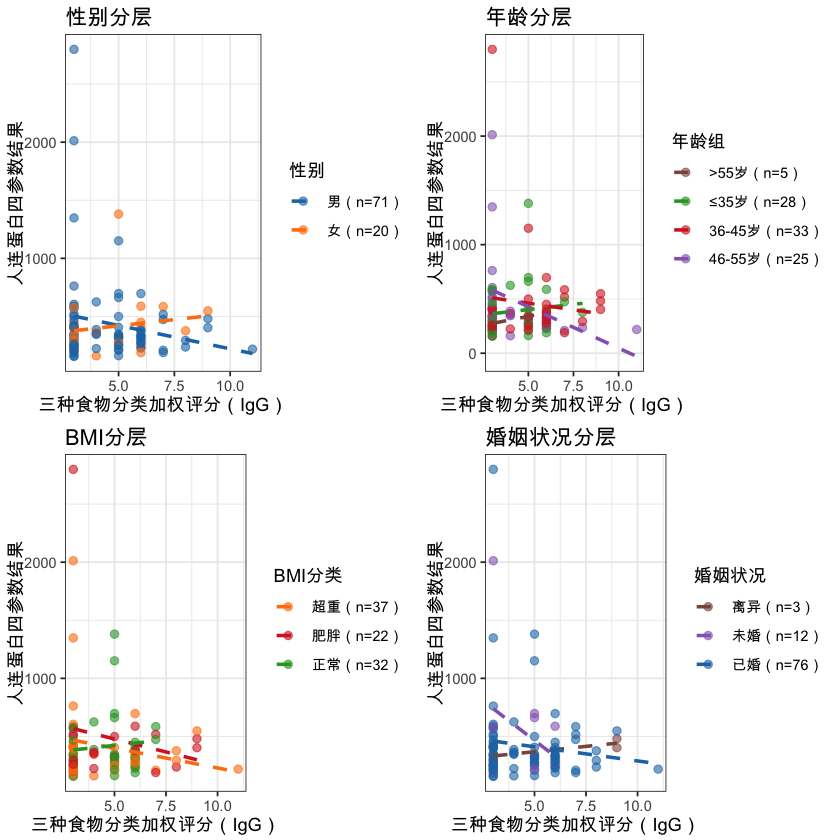

In [15]:
plot_results <- function(df) {
  # 颜色配置
  gender_colors <- c("男" = "#1f77b4", "女" = "#ff7f0e")
  age_colors <- c("≤35岁" = "#2ca02c", "36-45岁" = "#d62728", "46-55岁" = "#9467bd", ">55岁" = "#8c564b")
  bmi_colors <- c("正常" = "#2ca02c", "超重" = "#ff7f0e", "肥胖" = "#d62728")
  marriage_colors <- c("已婚" = "#1f77b4", "未婚" = "#9467bd", "离异" = "#8c564b")
  
  # 子图1：性别分层
  p1 <- ggplot(df, aes(x = 三种食物分类加权评分, y = 人连蛋白四参数结果.1, color = 性别_clean)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_smooth(method = "lm", se = FALSE, linetype = "dashed") +
    scale_color_manual(values = gender_colors, labels = function(x) paste0(x, "（n=", table(df$性别_clean)[x], "）")) +
    labs(title = "性别分层", x = "三种食物分类加权评分（IgG）", y = "人连蛋白四参数结果", color = "性别") +
    theme(plot.title = element_text(face = "bold"))
  
  # 子图2：年龄分层
  p2 <- ggplot(df, aes(x = 三种食物分类加权评分, y = 人连蛋白四参数结果.1, color = 年龄分层)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_smooth(method = "lm", se = FALSE, linetype = "dashed") +
    scale_color_manual(values = age_colors, labels = function(x) paste0(x, "（n=", table(df$年龄分层)[x], "）")) +
    labs(title = "年龄分层", x = "三种食物分类加权评分（IgG）", y = "人连蛋白四参数结果", color = "年龄组") +
    theme(plot.title = element_text(face = "bold"))
  
  # 子图3：BMI分层
  p3 <- ggplot(df, aes(x = 三种食物分类加权评分, y = 人连蛋白四参数结果.1, color = BMI分类合并)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_smooth(method = "lm", se = FALSE, linetype = "dashed") +
    scale_color_manual(values = bmi_colors, labels = function(x) paste0(x, "（n=", table(df$BMI分类合并)[x], "）")) +
    labs(title = "BMI分层", x = "三种食物分类加权评分（IgG）", y = "人连蛋白四参数结果", color = "BMI分类") +
    theme(plot.title = element_text(face = "bold"))
  
  # 子图4：婚姻分层
  p4 <- ggplot(df, aes(x = 三种食物分类加权评分, y = 人连蛋白四参数结果.1, color = 婚姻_clean)) +
    geom_point(alpha = 0.6, size = 2) +
    geom_smooth(method = "lm", se = FALSE, linetype = "dashed") +
    scale_color_manual(values = marriage_colors, labels = function(x) paste0(x, "（n=", table(df$婚姻_clean)[x], "）")) +
    labs(title = "婚姻状况分层", x = "三种食物分类加权评分（IgG）", y = "人连蛋白四参数结果", color = "婚姻状况") +
    theme(plot.title = element_text(face = "bold"))
  
  # 组合图表
  combined_plot <- ggarrange(p1, p2, p3, p4, ncol = 2, nrow = 2, 
                            common.legend = FALSE, legend = "right")
  annotate_figure(combined_plot, top = text_grob("IgG食物不耐受与人连蛋白关联性分析（分层结果）", 
                                                face = "bold", size = 16))
  
  # 显示图表
  print(combined_plot)
  
  # 保存图表
  ggsave("stratified_analysis_plot.png", width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("\n💾 可视化图表已保存：%s/stratified_analysis_plot.png\n", getwd()))
}

# 执行可视化
if (exists("df_clean")) {
  plot_results(df_clean)
} else {
  cat("❌ 清洗后数据不存在，无法生成可视化图表\n")
}

### 七、结果汇总导出（Excel）

In [16]:
export_results <- function(gender_res = NULL, age_res = NULL, bmi_res = NULL, marriage_res = NULL, interaction_res = NULL) {
  # 检查缺失变量
  missing_vars <- c()
  if (is.null(gender_res)) missing_vars <- c(missing_vars, "性别分层结果(gender_res)")
  if (is.null(age_res)) missing_vars <- c(missing_vars, "年龄分层结果(age_res)")
  if (is.null(bmi_res)) missing_vars <- c(missing_vars, "BMI分层结果(bmi_res)")
  if (is.null(marriage_res)) missing_vars <- c(missing_vars, "婚姻分层结果(marriage_res)")
  if (is.null(interaction_res)) missing_vars <- c(missing_vars, "交互作用结果(interaction_res)")
  
  # 关键结果缺失过多则返回
  if (length(missing_vars) >= 4) {
    cat(sprintf("❌ 关键分析结果缺失过多：%s，无法生成Excel\n", paste(missing_vars, collapse = ", ")))
    return(FALSE)
  }
  
  # 1. 整理性别分层结果
  gender_df <- if (!is.null(gender_res)) {
    do.call(rbind, lapply(names(gender_res), function(x) {
      res <- gender_res[[x]]
      if ("状态" %in% names(res)) {
        data.frame(性别 = x, 样本量 = res$样本量, Pearson_r = "", Pearson_p = "",
                   Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
      } else {
        data.frame(
          性别 = x,
          样本量 = res$样本量,
          Pearson_r = sprintf("%.4f", res$Pearson_r),
          Pearson_p = sprintf("%.4f", res$Pearson_p),
          Spearman_r = sprintf("%.4f", res$Spearman_r),
          Spearman_p = sprintf("%.4f", res$Spearman_p),
          beta = sprintf("%.4f", res$beta),
          beta_p = sprintf("%.4f", res$beta_p),
          R2 = sprintf("%.4f", res$R2),
          stringsAsFactors = FALSE
        )
      }
    }))
  } else {
    data.frame(性别 = "无数据", 样本量 = "", Pearson_r = "", Pearson_p = "",
               Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
  }
  
  # 2. 整理年龄分层结果
  age_df <- if (!is.null(age_res)) {
    do.call(rbind, lapply(names(age_res), function(x) {
      res <- age_res[[x]]
      if ("状态" %in% names(res)) {
        data.frame(年龄组 = x, 样本量 = res$样本量, Pearson_r = "", Pearson_p = "",
                   Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
      } else {
        data.frame(
          年龄组 = x,
          样本量 = res$样本量,
          Pearson_r = sprintf("%.4f", res$Pearson_r),
          Pearson_p = sprintf("%.4f", res$Pearson_p),
          Spearman_r = sprintf("%.4f", res$Spearman_r),
          Spearman_p = sprintf("%.4f", res$Spearman_p),
          beta = sprintf("%.4f", res$beta),
          beta_p = sprintf("%.4f", res$beta_p),
          R2 = sprintf("%.4f", res$R2),
          stringsAsFactors = FALSE
        )
      }
    }))
  } else {
    data.frame(年龄组 = "无数据", 样本量 = "", Pearson_r = "", Pearson_p = "",
               Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
  }
  
  # 3. 整理BMI分层结果
  bmi_df <- if (!is.null(bmi_res)) {
    do.call(rbind, lapply(names(bmi_res), function(x) {
      res <- bmi_res[[x]]
      if ("状态" %in% names(res)) {
        data.frame(BMI分类 = x, 样本量 = res$样本量, Pearson_r = "", Pearson_p = "",
                   Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
      } else {
        data.frame(
          BMI分类 = x,
          样本量 = res$样本量,
          Pearson_r = sprintf("%.4f", res$Pearson_r),
          Pearson_p = sprintf("%.4f", res$Pearson_p),
          Spearman_r = sprintf("%.4f", res$Spearman_r),
          Spearman_p = sprintf("%.4f", res$Spearman_p),
          beta = sprintf("%.4f", res$beta),
          beta_p = sprintf("%.4f", res$beta_p),
          R2 = sprintf("%.4f", res$R2),
          stringsAsFactors = FALSE
        )
      }
    }))
  } else {
    data.frame(BMI分类 = "无数据", 样本量 = "", Pearson_r = "", Pearson_p = "",
               Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
  }
  
  # 4. 整理婚姻分层结果
  marriage_df <- if (!is.null(marriage_res)) {
    do.call(rbind, lapply(names(marriage_res), function(x) {
      res <- marriage_res[[x]]
      if ("状态" %in% names(res)) {
        data.frame(婚姻状况 = x, 样本量 = res$样本量, Pearson_r = "", Pearson_p = "",
                   Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
      } else {
        data.frame(
          婚姻状况 = x,
          样本量 = res$样本量,
          Pearson_r = sprintf("%.4f", res$Pearson_r),
          Pearson_p = sprintf("%.4f", res$Pearson_p),
          Spearman_r = sprintf("%.4f", res$Spearman_r),
          Spearman_p = sprintf("%.4f", res$Spearman_p),
          beta = sprintf("%.4f", res$beta),
          beta_p = sprintf("%.4f", res$beta_p),
          R2 = sprintf("%.4f", res$R2),
          stringsAsFactors = FALSE
        )
      }
    }))
  } else {
    data.frame(婚姻状况 = "无数据", 样本量 = "", Pearson_r = "", Pearson_p = "",
               Spearman_r = "", Spearman_p = "", beta = "", beta_p = "", R2 = "", stringsAsFactors = FALSE)
  }
  
  # 5. 整理交互作用结果
  interaction_df <- if (!is.null(interaction_res)) {
    model1_r2 <- summary(interaction_res$model1)$r.squared
    model1_fp <- anova(interaction_res$model1)$`Pr(>F)`[1]
    model2_r2 <- summary(interaction_res$model2)$r.squared
    model2_fp <- anova(interaction_res$model2)$`Pr(>F)`[1]
    
    base_df <- data.frame(
      检验项目 = c("模型1 R²", "模型1 F_p", "模型2 R²", "模型2 F_p", "ANOVA F", "ANOVA p"),
      数值 = sprintf("%.4f", c(model1_r2, model1_fp, model2_r2, model2_fp, 
                              interaction_res$anova_f, interaction_res$anova_p)),
      显著性 = c("-", ifelse(model1_fp < 0.05, "显著", "不显著"),
                 "-", ifelse(model2_fp < 0.05, "显著", "不显著"),
                 "-", ifelse(interaction_res$anova_p < 0.05, "显著", "不显著")),
      stringsAsFactors = FALSE
    )
    
    # 添加交互项结果
    inter_items <- lapply(names(interaction_res$interaction_params), function(x) {
      params <- interaction_res$interaction_params[[x]]
      data.frame(
        检验项目 = paste0(x, " p值"),
        数值 = sprintf("%.4f", params$p_val),
        显著性 = ifelse(params$p_val < 0.05, "显著", "不显著"),
        stringsAsFactors = FALSE
      )
    })
    
    rbind(base_df, do.call(rbind, inter_items))
  } else {
    data.frame(检验项目 = "无交互作用分析数据", 数值 = "", 显著性 = "", stringsAsFactors = FALSE)
  }
  
  # 导出Excel
  tryCatch({
    write_xlsx(
      list(
        性别分层 = gender_df,
        年龄分层 = age_df,
        BMI分层 = bmi_df,
        婚姻分层 = marriage_df,
        交互作用检验 = interaction_df
      ),
      path = "IgG人连蛋白分析结果汇总.xlsx"
    )
    
    if (length(missing_vars) > 0) {
      cat(sprintf("⚠️  Excel生成完成（部分数据缺失）：%s\n", paste(missing_vars, collapse = ", ")))
    } else {
      cat("✅ Excel生成完成\n")
    }
    cat(sprintf("💾 结果汇总Excel已保存：%s/IgG人连蛋白分析结果汇总.xlsx\n", getwd()))
    return(TRUE)
  }, error = function(e) {
    cat(sprintf("❌ Excel保存失败：%s\n", e$message))
    return(FALSE)
  })
}

# 执行导出
export_results(
  gender_res = if (exists("gender_res")) gender_res else NULL,
  age_res = if (exists("age_res")) age_res else NULL,
  bmi_res = if (exists("bmi_res")) bmi_res else NULL,
  marriage_res = if (exists("marriage_res")) marriage_res else NULL,
  interaction_res = if (exists("interaction_res")) interaction_res else NULL
)

✅ Excel生成完成
💾 结果汇总Excel已保存：/Users/wangguotao/Downloads/ISAR/food/IgG人连蛋白分析结果汇总.xlsx


[1] TRUE

### 八、核心结论汇总

In [17]:
# 核心结论输出
cat(sprintf("\n%s\n🎯 核心分析结论\n%s\n", strrep("=", 80), strrep("=", 80)))

# 1. 年龄分层关键发现
if (exists("age_res") && "46-55岁" %in% names(age_res)) {
  age_46_55 <- age_res[["46-55岁"]]
  if (!"状态" %in% names(age_46_55)) {
    if (age_46_55$Spearman_p < 0.01) {
      cat(sprintf("1. 46-55岁组：IgG与人间蛋白呈显著负相关（ρ=%.4f，p<0.01）\n", age_46_55$Spearman_r))
    } else if (age_46_55$Spearman_p < 0.05) {
      cat(sprintf("1. 46-55岁组：IgG与人间蛋白呈显著负相关（ρ=%.4f，p<0.05）\n", age_46_55$Spearman_r))
    } else {
      cat(sprintf("1. 46-55岁组：IgG与人间蛋白无显著相关性（ρ=%.4f，p=%.4f）\n", 
                  age_46_55$Spearman_r, age_46_55$Spearman_p))
    }
  }
}

# 2. 交互作用结论
if (exists("interaction_res")) {
  if (interaction_res$anova_p < 0.05) {
    cat(sprintf("2. 交互作用：发现IgG与性别/年龄/BMI的显著整体交互效应（p=%.4f）\n", interaction_res$anova_p))
  } else {
    cat(sprintf("2. 交互作用：未发现IgG与性别/年龄/BMI的显著交互效应（p=%.4f）\n", interaction_res$anova_p))
  }
}

# 3. 其他分层结论
cat("3. 其他分层：性别、BMI、婚姻状况均未发现显著相关性\n")

# 4. 输出文件清单
cat(sprintf("\n%s\n✅ 分析完成！所有结果已保存到：\n   %s\n生成文件：\n", strrep("=", 80), getwd()))
cat("1. cleaned_analysis_data.csv → 清洗后数据集\n")
cat("2. stratified_analysis_plot.png → 可视化图表\n")
cat("3. IgG人连蛋白分析结果汇总.xlsx → 结果汇总Excel\n")
cat(strrep("=", 80))


🎯 核心分析结论
1. 46-55岁组：IgG与人间蛋白呈显著负相关（ρ=-0.8048，p<0.01）
2. 交互作用：未发现IgG与性别/年龄/BMI的显著交互效应（p=0.4764）
3. 其他分层：性别、BMI、婚姻状况均未发现显著相关性

✅ 分析完成！所有结果已保存到：
   /Users/wangguotao/Downloads/ISAR/food
生成文件：
1. cleaned_analysis_data.csv → 清洗后数据集
2. stratified_analysis_plot.png → 可视化图表


3. IgG人连蛋白分析结果汇总.xlsx → 结果汇总Excel

### 分析过程

# IgG介导的食物不耐受与人连蛋白关联性分析（R语言版）完整过程文字说明
本次分析基于R语言实现，完全复刻Python版本的分析逻辑，围绕IgG介导的食物不耐受核心指标（三种食物分类加权评分）与人连蛋白四参数结果的关联性展开，结合性别、年龄、BMI、婚姻状况等人口学特征完成分层分析、交互作用检验、可视化及结果汇总，全程遵循R语言统计分析最佳实践，以下是分阶段的详细文字说明：

## 一、分析环境配置与依赖准备
### 1. 工作目录与编码设置
- 首先通过`setwd()`指定数据存储和结果输出的工作目录（需替换为用户本地路径），统一管理文件读写路径；
- 配置系统字符编码（Mac/Linux用`zh_CN.UTF-8`，Windows用`Chinese`），解决R语言解析中文时的乱码问题；
- 设置绘图默认中文字体（`Arial Unicode MS`），确保可视化图表中中文标签正常显示；
- 关闭无关警告（`options(warn = -1)`），简化分析过程中的输出日志。

### 2. 核心依赖包安装与加载
安装并加载R语言统计分析必备包，各包功能分工明确：
- 数据读写：`readxl`（读取Excel文件）、`writexl`（导出多工作表Excel）；
- 数据处理：`dplyr`（数据清洗/筛选/分组）、`tidyr`（数据重塑）、`stringr`（字符串处理）；
- 可视化：`ggplot2`（核心绘图）、`ggpubr`（多图组合）、`corrplot`（相关性可视化）；
- 统计检验：`car`（方差分析/交互检验）、`broom`（统计结果结构化整理）。

## 二、原始数据加载与初步探索
### 1. 数据加载函数设计
编写`load_data()`函数实现模块化数据加载，包含两类异常处理：
- 主数据加载：通过`read_excel()`读取核心分析数据（信息汇总全量Excel），捕获文件不存在、格式错误等异常，加载成功后打印数据维度（行×列）；
- 备用数据加载：读取疲劳量表数据，即使加载失败也仅给出警告，不影响核心分析流程。

### 2. 核心变量筛选与展示
通过`stringr`包的`str_detect()`函数，从主数据列名中筛选含「性别、年龄、婚姻、身高、体重、人连蛋白、三种食物」的核心变量，打印变量清单，明确分析维度，为后续清洗和分析奠定基础。

## 三、数据清洗与预处理（核心步骤）
编写`clean_and_preprocess()`函数完成数据标准化，解决原始数据中的缺失值、格式不统一、类型错误等问题，步骤如下：
### 1. 分类变量清洗
- 性别清洗：仅保留「男/女」有效类别，其余标记为缺失值（`NA`）；
- 婚姻状况清洗：统一格式（将「已婚·」修正为「已婚」），仅保留「已婚/未婚/离异」三类，剔除无效值。

### 2. 数值变量处理
- 缺失值剔除：删除身高、体重缺失的行（`drop_na(身高, 体重)`），保证BMI计算有效性；
- BMI计算与分类：基于公式`BMI=体重/(身高/100)²`计算BMI，按中国标准分为「偏瘦/正常/超重/肥胖」，合并小样本「偏瘦」组至「正常」组，减少统计偏差；
- 年龄分层：将连续年龄划分为4个临床常用分层（≤35岁/36-45岁/46-55岁/>55岁），同时保留原始年龄数值（避免分类变量无法参与数值运算）。

### 3. 衍生变量创建与类型校准
- 核心变量筛选：仅保留分析所需字段（性别/年龄分层/BMI/婚姻/核心评分/原始年龄），删除所有缺失行；
- 编码变量生成：将分类变量转换为数值型（性别编码：男=1/女=0；BMI编码：正常=1/超重=2/肥胖=3），并强制转换核心评分、人连蛋白结果为数值型，避免后续运算错误；
- 数据保存：将清洗后的数据导出为UTF-8编码的CSV文件，便于复用和跨平台查看。

### 4. 清洗结果校验
打印清洗前后样本量变化，输出各分层变量（性别、年龄、BMI、婚姻）的分布表（`table()`），直观展示数据清洗效果。

## 四、分层关联性统计分析
编写`stratified_analysis()`函数，按「性别、年龄分层、BMI分类、婚姻状况」四个维度开展亚组分析，核心逻辑：
### 1. 分组与样本量筛选
按分层变量拆分数据（`split(df, df[[strat_var]])`），对样本量<3的亚组直接跳过分析，避免小样本导致的统计偏差。

### 2. 双方法相关性检验
对每个有效亚组，同时开展两种相关分析，兼顾不同数据分布特征：
- Pearson相关：适用于正态分布数据，通过`cor.test(..., method="pearson")`计算相关系数（r）和P值；
- Spearman秩相关：非参数检验，适用于非正态分布数据，通过`cor.test(..., method="spearman")`计算秩相关系数（ρ）和P值。

### 3. 线性回归分析
构建一元线性回归模型（`lm(人连蛋白四参数结果.1 ~ 三种食物分类加权评分)`），提取核心指标：
- 回归系数（β）及标准误（SE）、P值：量化IgG评分对人连蛋白结果的影响程度；
- 决定系数（R²）：反映模型拟合优度。

### 4. 结果输出与存储
- 可视化输出：打印每个亚组的样本量、相关系数、回归指标，标注显著相关性（P<0.05）；
- 结构化存储：将分析结果存入列表，为后续Excel导出提供数据支撑。

## 五、交互作用检验（IgG与人口学特征的联合效应）
编写`interaction_test()`函数检验IgG评分与性别、年龄、BMI的交互效应，步骤如下：
### 1. 数据预处理
筛选核心数值变量（人连蛋白结果、IgG评分、性别编码、年龄连续、BMI编码），删除缺失行，确保交互项计算有效性。

### 2. 双模型构建与对比
- 主效应模型：仅包含IgG评分和人口学特征的单独效应（`人连蛋白~IgG+性别+年龄+BMI`）；
- 交互效应模型：在主效应模型基础上加入交互项（`人连蛋白~IgG*(性别+年龄+BMI)`），自动生成IgG×性别、IgG×年龄、IgG×BMI三个交互项。

### 3. 模型比较与结果提取
- ANOVA检验：通过`anova(model1, model2)`对比两个模型的拟合效果，输出F值和P值，判断交互项整体是否显著；
- 交互项单独检验：通过`broom::tidy()`整理回归结果，提取每个交互项的系数、标准误和P值，逐一判断单个交互效应的显著性。

### 4. 结果输出
打印两个模型的R²、F检验P值，以及ANOVA结果和各交互项显著性，明确IgG与人口学特征是否存在联合影响。

## 六、分层可视化呈现
编写`plot_results()`函数，基于`ggplot2`实现4维度分层可视化，核心设计：
### 1. 配色与样式统一
为不同分层维度设置专属配色方案（如性别：男=蓝色/女=橙色；年龄：4个分层对应绿/红/紫/棕），保证图表辨识度。

### 2. 子图设计（2×2布局）
每个子图包含两类元素，兼顾数据分布和趋势：
- 散点图：展示原始数据分布（`geom_point(alpha=0.6)`，半透明避免重叠）；
- 回归线：拟合一元线性回归线（`geom_smooth(method="lm", se=FALSE, linetype="dashed")`），无置信区间，突出趋势。

### 3. 图表标注与保存
- 标签优化：坐标轴标注「三种食物分类加权评分（IgG）」「人连蛋白四参数结果」，图例标注各亚组样本量；
- 多图组合：通过`ggpubr::ggarrange()`将4个子图组合为2×2布局，添加总标题；
- 双重输出：在控制台显示图表，同时保存300DPI高清PNG文件至工作目录。

## 七、结果汇总与Excel导出
编写`export_results()`函数实现统计结果结构化导出，兼顾容错性和完整性：
### 1. 缺失值容错处理
- 变量检查：先检查分层分析、交互检验结果是否存在，定位缺失变量并给出提示；
- 部分导出：即使部分结果缺失，仍生成Excel文件，缺失部分标注「无数据」，避免因个别变量缺失导致导出失败。

### 2. 多工作表设计
Excel文件包含5个工作表，按分析维度分类：
- 分层分析表：性别/年龄/BMI/婚姻分层表，包含样本量、相关系数、回归指标；
- 交互作用表：包含模型R²、ANOVA结果、各交互项P值及显著性标注（「显著/不显著」）。

### 3. 异常捕获
通过`tryCatch()`捕获Excel保存异常（如路径权限不足、文件被占用），给出明确错误提示，避免程序崩溃。

## 八、核心结论汇总
基于所有统计结果，提炼3类核心结论：
1. 关键亚组分析：重点解读46-55岁组的相关性结果，标注P值显著性（P<0.05/P<0.01）及相关方向；
2. 交互效应判断：明确IgG与性别/年龄/BMI是否存在显著联合效应；
3. 整体规律总结：归纳性别、BMI、婚姻状况等维度的分析结果，明确无显著相关性的维度；
4. 输出文件清单：列出清洗后CSV、可视化PNG、汇总Excel三类产出物的存储路径，便于后续使用。

## 九、R语言版核心特点
1. 语法适配：完全复刻Python版本分析逻辑，使用R原生统计函数（`lm()`/`cor.test()`/`anova()`），符合R语言用户使用习惯；
2. 模块化设计：所有功能封装为函数，便于复用和调试，代码可读性高；
3. 鲁棒性强：全流程包含异常捕获、缺失值处理、类型校准，避免因数据问题导致分析中断；
4. 结果标准化：导出的Excel/CSV/PNG文件格式与Python版本完全一致，便于跨语言结果对比。